# Imports

In [2]:
import numpy as np
import sympy as sp
from numba import njit, prange

Mis funciones definidas en `/code/src/`

In [3]:
import sys
import os

# Navigate up to the 'code' directory, then into 'src'
sys.path.append(os.path.abspath('../src'))

# Import the functions
from dynamics import generate_orbit, generate_escape_time_fractal, generate_fatou_basins, make_generate_orbit_jitted, make_generate_escape_time_fractal_jitted, make_generate_fatou_basins_jitted
from utils import DynamicsPlotter

# Ejemplo del libro ($z \mapsto 2z - \frac{1}{z}$)

In [83]:
@njit
def R_njit(z):
    return 2*z - 1/z

In [84]:
generate_orbit_jitted = make_generate_orbit_jitted(R_njit)

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'Orbit'}>)

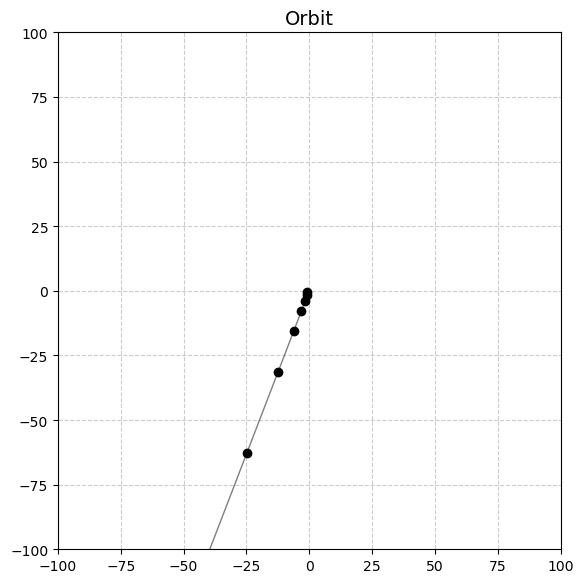

In [ ]:
x0 = np.random.uniform(-2, 2)
y0 = np.random.uniform(-2, 2)
z0 = complex(x0, y0)
max_iter = 100

orbit = generate_orbit_jitted(z0, max_iter=max_iter)

center = 0.0
max_distance_to_center = 100

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

plotter.plot_orbit(orbit)

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'Orbit'}>)

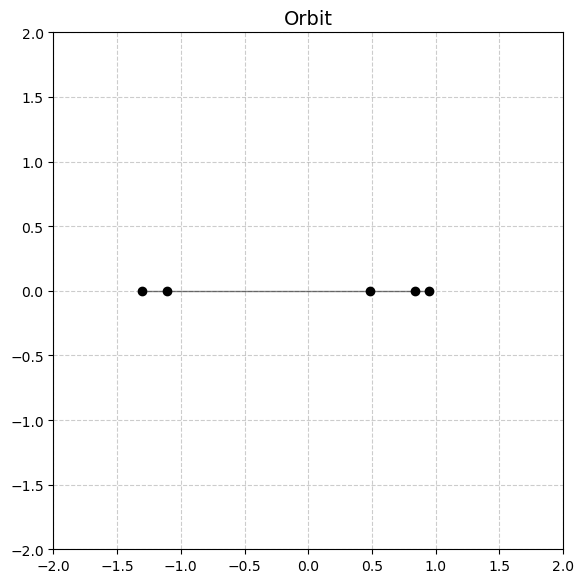

In [178]:
n = 4
x0 = np.random.uniform(1-1/(2**n), 1)
y0 = 0
z0 = complex(x0, y0)
max_iter = n

orbit = generate_orbit_jitted(z0, max_iter=max_iter)

center = 0.0
max_distance_to_center = 2

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

plotter.plot_orbit(orbit)